In [32]:
# Cargar librerias

import nltk
import re
import string
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from collections import Counter

#Descargamos los recursos necesarios de NLTK
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
# Crear función para conservar los emojis

def reemplazar_emojis(texto):
  """
  Convierte ciertos emojis frecuentes en etiquetas de texto.

  Esto es util porque:
  1. Conserva parte de la carga emocional o semantica.
  2. Evita perder informacion importante en tareas como analisis de sentimientos.
  3. Facilita el procesamiento posteriro, porque el emoji se vuelve texto.
  """
  mapa_emojis={
      "😡": " emoji_enojo ",
      "😃": " emoji_felicidad ",
      "😍": " emoji_amor ",
      "🍕": " emoji_pizza "
  }

  for emoji, etiqueta in mapa_emojis.items():
    texto= texto.replace(emoji, etiqueta)

  return texto

In [26]:
# Texto de prueba

texto_web = "<b>¡Pésimo servicio!</b> 😡 La comida llegó tarde. <br> Visiten http://quejas.com. Costó 250 pesos. &"

print(" Texto original \n")
print(texto_web)

 Texto original 

<b>¡Pésimo servicio!</b> 😡 La comida llegó tarde. <br> Visiten http://quejas.com. Costó 250 pesos. &


In [28]:
# Limpieza básica

# Paso 1: quitar etiquetas HTML
texto_sin_html = re.sub(r'<.*?>', ' ', texto_web)

# Paso 2: quitar URLs
texto_sin_urls = re.sub(r'http\S+|www\S+', ' ', texto_sin_html)

# Paso 3: convertir el texto a minusculas
texto_minusculas = texto_sin_urls.lower()

# Paso 4: convertir emojis en etiquetas textuales
texto_con_emojis = reemplazar_emojis(texto_minusculas)

# Paso 5: quitar simbolos raros
# Conservamos letras, números, espacios y algunos signos comunes del español
texto_limpio_parcial = re.sub(r'[^\w\sáéíóúüñ¡!¿?.,]', ' ', texto_con_emojis)

print(texto_limpio_parcial)

 ¡pésimo servicio!   emoji_enojo  la comida llegó tarde.   visiten   costó 250 pesos.  


In [30]:
# Normalización

# Paso 6: Quitar puntuaciones
texto_sin_puntuacion = texto_limpio_parcial.translate(
    str.maketrans('', '', string.punctuation + '¡¿'))

# Paso 7: Quitar números
# Ojo: Esto depende del problema. Si quisieramos analizar
# fechas o cantidades, entonces no deberiamos quitar los números
texto_sin_numeros = re.sub(r'\d+', ' ', texto_sin_puntuacion)

# Paso 8: Quitar espacios extra
texto_normalizado = re.sub(r'\s+', ' ', texto_sin_numeros).strip()

print(texto_normalizado)

pésimo servicio emojienojo la comida llegó tarde visiten costó pesos


In [33]:
# Tokenizacion
tokens = word_tokenize(texto_normalizado, language='spanish')

print(tokens)

['pésimo', 'servicio', 'emojienojo', 'la', 'comida', 'llegó', 'tarde', 'visiten', 'costó', 'pesos']


In [34]:
# Eliminar las stopwords

# Carganamos las stopwords en español
# Las sotpwords son palabras  muy frecuentes que en muchos casos
# no aportan demasiado significado temático
stop_words_es = set(stopwords.words('spanish'))

# En el análisis de sentimientos conviene conservar algunas negaciones
# por que cambian completamente el significado
stop_words_es = stop_words_es - {'no', 'ni', 'nunca'}

tokens_sin_stopwords = [ palabra for palabra in tokens if palabra not in stop_words_es]

print(tokens_sin_stopwords)

['pésimo', 'servicio', 'emojienojo', 'comida', 'llegó', 'tarde', 'visiten', 'costó', 'pesos']


In [35]:
# Stemming en español

stemmer = SnowballStemmer("spanish")

tokens_stem = [stemmer.stem(palbra) for palbra in tokens_sin_stopwords]

print(tokens_stem)

['pesim', 'servici', 'emojienoj', 'com', 'lleg', 'tard', 'visit', 'cost', 'pes']


In [38]:
# Comparación

print(" Comparacion del proceso")
print("-" * 50)
print("Original: ")
print(texto_web)

print("\nNormalizado:")
print(texto_normalizado)

print("\n Tokens")
print(tokens)

print("\nSin stopwords:")
print(tokens_sin_stopwords)

print("\nCon stemming:")
print(tokens_stem)

 Comparacion del proceso
--------------------------------------------------
Original: 
<b>¡Pésimo servicio!</b> 😡 La comida llegó tarde. <br> Visiten http://quejas.com. Costó 250 pesos. &

Normalizado:
pésimo servicio emojienojo la comida llegó tarde visiten costó pesos

 Tokens
['pésimo', 'servicio', 'emojienojo', 'la', 'comida', 'llegó', 'tarde', 'visiten', 'costó', 'pesos']

Sin stopwords:
['pésimo', 'servicio', 'emojienojo', 'comida', 'llegó', 'tarde', 'visiten', 'costó', 'pesos']

Con stemming:
['pesim', 'servici', 'emojienoj', 'com', 'lleg', 'tard', 'visit', 'cost', 'pes']


In [41]:
# Metricas antes y despues

def resumen_tokens(lista_tokens, nombre="Resumen"):
  """
  Mostraremos un pequeño resumen estadistico de una lista de tokens

  Parametros:
  lista_tokens: lista de palabras
  nombre: titulo del resumen
  """

  print(f"\n{nombre}")
  print("Cantidad total de tokens:", len(lista_tokens))
  print("Vocabulario único:", len(set(lista_tokens)))
  print("Top 5 palabras:", Counter(lista_tokens).most_common(5))

resumen_tokens(tokens, "Antes de quitar stopwords")

resumen_tokens(tokens_sin_stopwords, "Despues de quitar stopwords")


Antes de quitar stopwords
Cantidad total de tokens: 10
Vocabulario único: 10
Top 5 palabras: [('pésimo', 1), ('servicio', 1), ('emojienojo', 1), ('la', 1), ('comida', 1)]

Despues de quitar stopwords
Cantidad total de tokens: 9
Vocabulario único: 9
Top 5 palabras: [('pésimo', 1), ('servicio', 1), ('emojienojo', 1), ('comida', 1), ('llegó', 1)]


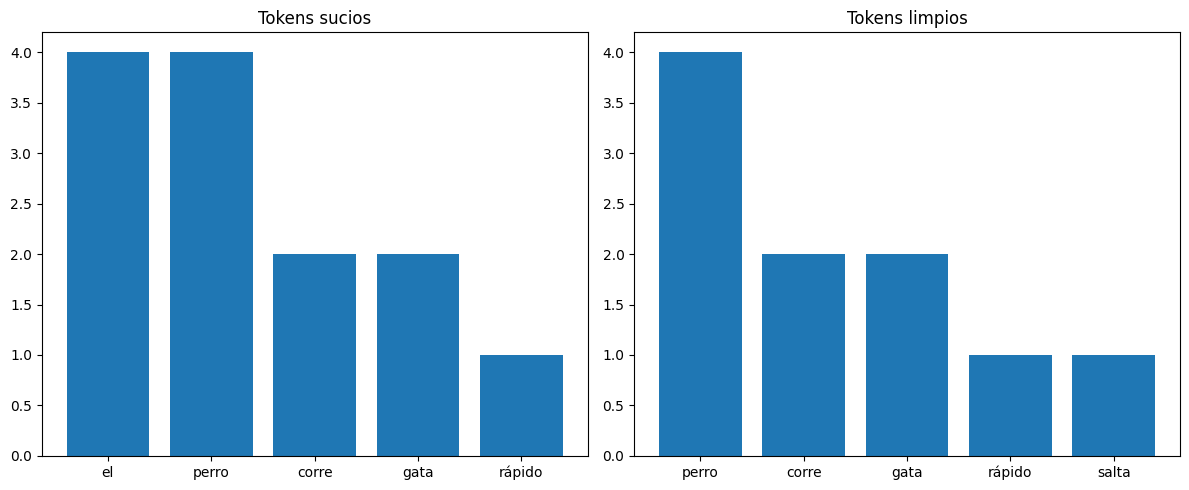

In [44]:
# Visualización grafica antes y despues

# Texto mas largo al que usamos antes
texto_prueba= """
El perro corre rápido, el perro salta alto.
La gata corre con el perro.
El perro es feliz.
Pero las gata no quiere jugar.
"""
tokens_sucios= word_tokenize(texto_prueba.lower(), language='spanish')

tokens_sucios = [ t for t in tokens_sucios if t.isalpha()]

tokens_limpios= [t for t in tokens_sucios if t not in stop_words_es]

top_sucios= Counter(tokens_sucios).most_common(5)
top_limpios= Counter(tokens_limpios).most_common(5)

pal_sucias, freq_sucias = zip(*top_sucios)
pal_limpios, freq_limpios = zip(*top_limpios)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(pal_sucias, freq_sucias)
plt.title("Tokens sucios")

plt.subplot(1,2,2)
plt.bar(pal_limpios, freq_limpios)
plt.title("Tokens limpios")

plt.tight_layout()
plt.show()